# Single-lens aperture forward model

Forward model a circular aperture through a single lens and compare the probe plane with the FFT of the aperture field.

## Setup

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.8"

import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
import optax

from temgym_core.components import Detector
from temgym_core.constants import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_jax_scan
from temgym_core.gaussian import Lens, circular_input_wave, run_to_end

jax.config.update("jax_enable_x64", True)

%matplotlib widget

## Geometry and grids

In [2]:
voltage = 100_000  # V
wavelength = energy2wavelength(voltage)

input_window_width = 50e-6
aperture_radius = 10e-6
lens_f = 1e-3

Nx = Ny = 32
input_pixel = input_window_width / Nx
output_pixel = float(wavelength) * abs(lens_f) / input_window_width

input_grid = Detector(
    z=0.0,
    pixel_size=(input_pixel, input_pixel),
    shape=(Ny, Nx),
)
output_grid = Detector(
    z=2 * lens_f,
    pixel_size=(output_pixel, output_pixel),
    shape=(Ny, Nx),
)

input_extent = input_grid.extent
output_extent = output_grid.extent
output_x, output_y = output_grid.coords_1d

## Aperture field

Number of input rays: 31416


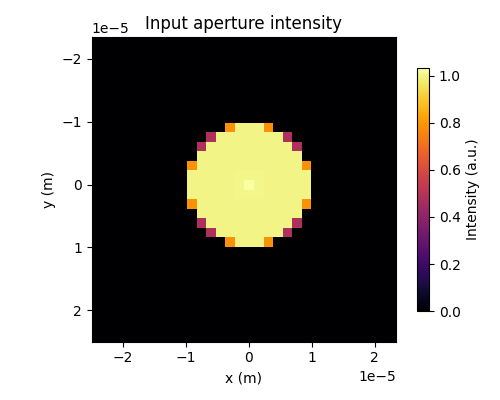

In [3]:
input_waist = 2e-7
rays_in = circular_input_wave(
    voltage=voltage,
    aperture_radius=aperture_radius,
    waist=input_waist,
    offset_xy=(0.0, 0.0),
    sampling="uniform",
).to_vector()

print('Number of input rays:', rays_in.x.shape[0])

rays_after_aperture = run_to_end(rays_in, ())
input_aperture_field = evaluate_gaussians_jax_scan(
    rays_after_aperture, input_grid, batch_size=128
)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(
    jnp.abs(input_aperture_field),
    extent=input_extent,
    origin="lower",
    cmap="inferno",
)
ax.set_title("Input aperture intensity")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Intensity (a.u.)")
fig.tight_layout()

## Propagate through the lens

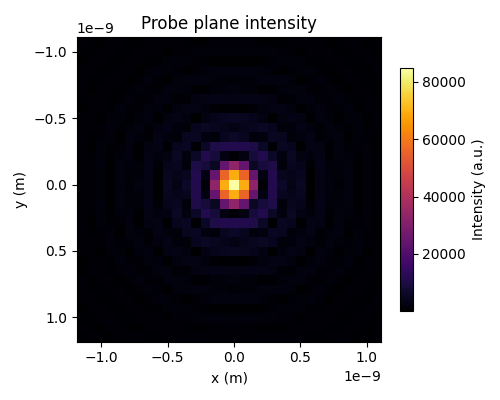

In [4]:
lens = Lens(z=lens_f, focal_length=lens_f)
run_to_end_vmapped = jax.vmap(run_to_end, in_axes=(0, None))

rays_after_lens = run_to_end_vmapped(rays_in, (lens, output_grid))
probe_field = evaluate_gaussians_jax_scan(
    rays_after_lens, output_grid, batch_size=128
)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(
    jnp.abs(probe_field),
    extent=output_extent,
    origin="lower",
    cmap="inferno",
)
ax.set_title("Probe plane intensity")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Intensity (a.u.)")
fig.tight_layout()

## FFT reference from the aperture field

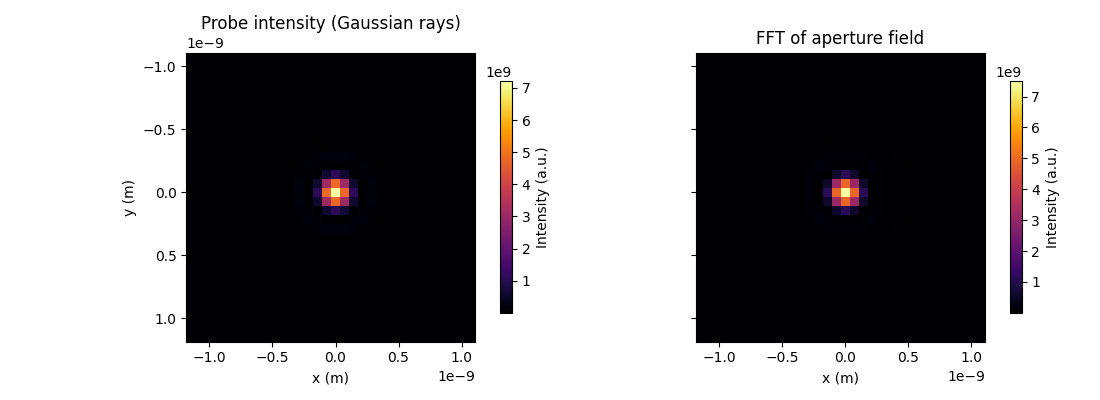

In [5]:
du = input_pixel

diffraction_of_aperture = jnp.fft.ifftshift(jnp.fft.fft2(input_aperture_field))
# Energy-conserving scaling for the FFT propagation to the focal plane
diffraction_of_aperture *= (du * du) / (1j * wavelength * lens_f)

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
im0 = ax[0].imshow(
    jnp.abs(probe_field) ** 2,
    extent=output_extent,
    origin="lower",
    cmap="inferno",
)
ax[0].set_title("Probe intensity (Gaussian rays)")

im1 = ax[1].imshow(
    jnp.abs(diffraction_of_aperture) ** 2,
    extent=output_extent,
    origin="lower",
    cmap="inferno",
)
ax[1].set_title("FFT of aperture field")

for axis in ax:
    axis.set_xlabel("x (m)")
ax[0].set_ylabel("y (m)")

fig.colorbar(im0, ax=ax[0], shrink=0.8, label="Intensity (a.u.)")
fig.colorbar(im1, ax=ax[1], shrink=0.8, label="Intensity (a.u.)")
fig.tight_layout()

## Central cross-section

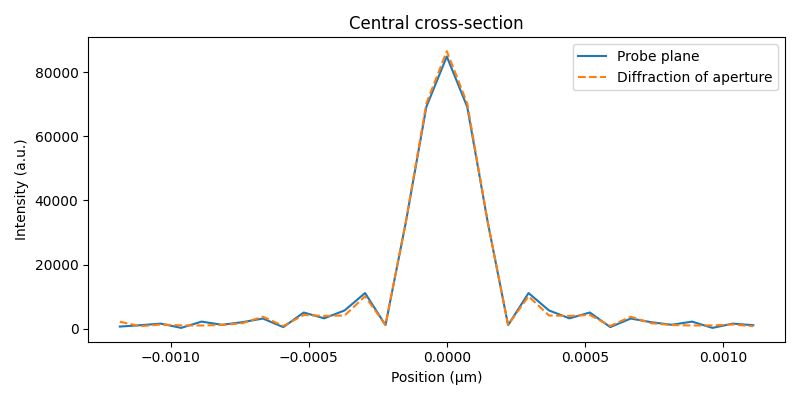

In [6]:
center = Nx // 2
output_x_um = np.asarray(output_x) * 1e6

probe_line = np.abs(np.asarray(probe_field)[center, :])
fft_line = np.abs(np.asarray(diffraction_of_aperture)[center, :])

plt.figure(figsize=(8, 4))
plt.plot(output_x_um, probe_line, label="Probe plane")
plt.plot(output_x_um, fft_line, "--", label="Diffraction of aperture")
plt.xlabel("Position (µm)")
plt.ylabel("Intensity (a.u.)")
plt.title("Central cross-section")
plt.legend()
plt.tight_layout()

## Fit focal length from intensity-only defocus series

We assume the object field is known, the detector plane is fixed, and the sample is moved by a known axial offset $\Delta z$. We fit $f$ by matching two (or more) intensity measurements taken at different lens positions.

In [7]:
# Explore 2D loss landscape over (f, z_lens_1)
z_det = 2.0e-3
z_offset = 5e-8  # known sample move per image
output_grid_fit = Detector(
    z=z_det,
    pixel_size=(output_pixel, output_pixel),
    shape=(Ny, Nx),
)

eps = 1e-12
lambda_A = 1
A_target = 0.0
B_target = lens_f  # Fourier plane expectation

def abcd(z1, z2, f):
    A = 1.0 - z2 / f
    return A

def log_intensity_loss(I_sim, I_target):
    return jnp.mean((jnp.log(I_sim + eps) - jnp.log(I_target + eps)) ** 2)

def forward_intensity_heatmap(f, z_lens):
    lens_fit = Lens(z=z_lens, focal_length=f)
    rays_out = run_to_end_vmapped(rays_in, (lens_fit, output_grid_fit))
    field = evaluate_gaussians_jax_scan(rays_out, output_grid_fit, batch_size=8)
    intensity = jnp.abs(field) ** 2
    return intensity / jnp.sum(intensity)

f_true = lens_f
z_lens_1_true = lens_f

# Use 5 images to fit both f and z_lens_1
z_offsets = jnp.array([0.0, z_offset, 2.0 * z_offset, 3.0 * z_offset, 4.0 * z_offset])
z_lens_list = z_lens_1_true + z_offsets
I_meas = jax.vmap(lambda z: forward_intensity_heatmap(f_true, z))(z_lens_list)

def loss_for_params(f, z_lens_1):
    def one(z_offset, I_target):
        z_lens = z_lens_1 + z_offset
        z1 = z_lens
        z2 = z_det - z_lens
        I_sim = forward_intensity_heatmap(f, z_lens)
        data = log_intensity_loss(I_sim, I_target)
        A = abcd(z1, z2, f)
        penalty = lambda_A * (A - A_target) ** 2
        return data + penalty

    return jnp.sum(jax.vmap(one)(z_offsets, I_meas))

# Scan ranges around truth (coarse grid for speed)
f_scan = jnp.linspace(0.8 * lens_f, 1.2 * lens_f, 25)
z_scan = jnp.linspace(0.8 * lens_f, 1.2 * lens_f, 25)

loss_grid = jax.vmap(
    lambda f: jax.vmap(lambda z: loss_for_params(f, z))(z_scan)
)(f_scan)

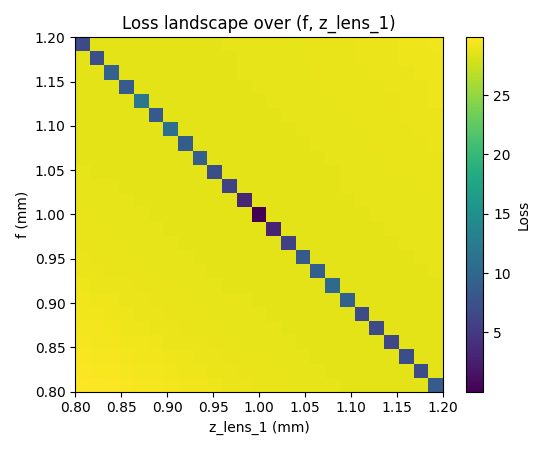

In [8]:

plt.figure(figsize=(5.5, 4.5))
plt.imshow(
    np.asarray(loss_grid),
    origin="lower",
    aspect="auto",
    extent=[z_scan[0] * 1e3, z_scan[-1] * 1e3, f_scan[0] * 1e3, f_scan[-1] * 1e3],
    cmap="viridis",
 )
plt.colorbar(label="Loss")
plt.xlabel("z_lens_1 (mm)")
plt.ylabel("f (mm)")
plt.title("Loss landscape over (f, z_lens_1)")
plt.tight_layout()

In [9]:
# Use the JAX Gaussian-ray forward model with optax/adam optimization

# Known geometry (object at z=0, detector at fixed z_det)
z_det = 2.0e-3
z_offset = 5e-8  # known sample move per image

output_grid_fit = Detector(
    z=z_det,
    pixel_size=(output_pixel, output_pixel),
    shape=(Ny, Nx),
)

eps = 1e-12
lambda_A = 1
A_target = 0.0

def abcd(z1, z2, f):
    A = 1.0 - z2 / f
    return A

def log_intensity_loss(I_sim, I_target):
    return jnp.mean((jnp.log(I_sim + eps) - jnp.log(I_target + eps)) ** 2)

def forward_intensity(f, z_lens):
    lens_fit = Lens(z=z_lens, focal_length=f)
    rays_out = run_to_end_vmapped(rays_in, (lens_fit, output_grid_fit))
    field = evaluate_gaussians_jax_scan(rays_out, output_grid_fit, batch_size=16)
    intensity = jnp.abs(field) ** 2
    return intensity / jnp.sum(intensity)

# Synthetic measurements (replace with your measured intensities)
f_true = lens_f
z_lens_1_true = lens_f

# Use 5 images to fit both f and z_lens_1
z_offsets = jnp.array([0.0, z_offset, 2.0 * z_offset, 3.0 * z_offset, 4.0 * z_offset])
z_lens_list = z_lens_1_true + z_offsets

I_meas = jax.vmap(lambda z: forward_intensity(f_true, z))(z_lens_list)


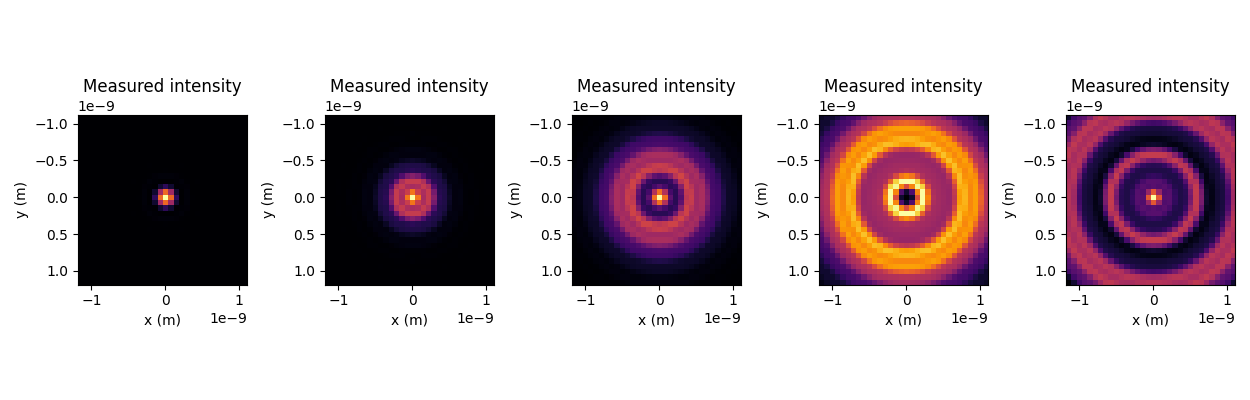

In [10]:
fig, axs = plt.subplots(1, len(I_meas), figsize=(5 * len(I_meas) / 2, 4))
for ax, I in zip(axs, I_meas):

    ax.imshow(
        np.asarray(I),
        extent=output_grid_fit.extent,
        origin="lower",
        cmap="inferno",
    )
    ax.set_title("Measured intensity")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
plt.tight_layout()

In [11]:
def unpack_params(params):
    f = jax.nn.softplus(params[0]) + eps
    z_lens_1 = jax.nn.softplus(params[1]) + eps
    return f, z_lens_1

def softplus_inv(x):
    return jnp.log(jnp.expm1(x))

@jax.jit
def loss_fn(params):
    f, z_lens_1 = unpack_params(params)
    def one(z_offset, I_target):
        z_lens = z_lens_1 + z_offset
        z1 = z_lens
        z2 = z_det - z_lens
        I_sim = forward_intensity(f, z_lens)
        data = log_intensity_loss(I_sim, I_target)
        A = abcd(z1, z2, f)
        penalty = lambda_A * (A - A_target) ** 2
        return data + penalty

    return jnp.sum(jax.vmap(one)(z_offsets, I_meas))

# Initial guess (could be random or based on prior knowledge)
params_init = jnp.array([softplus_inv(0.9 * lens_f), softplus_inv(0.9 * lens_f)])

n_steps = 50

# Optax L-BFGS with zoom linesearch (preferred over Adam for deterministic smooth loss)
optimizer = optax.lbfgs(memory_size=10)
opt_state = optimizer.init(params_init)
value_and_grad = optax.value_and_grad_from_state(loss_fn)

loss_history = []
f_history = []
z_history = []

# run optimization (keep histories as Python lists)
params = params_init
opt_state_local = opt_state
loss_history.clear()
f_history.clear()
z_history.clear()

for i in range(n_steps):
    loss, grads = value_and_grad(params, state=opt_state_local)
    updates, opt_state_local = optimizer.update(
        grads,
        opt_state_local,
        params=params,
        value=loss,
        grad=grads,
        value_fn=loss_fn,
    )
    params = optax.apply_updates(params, updates)
    f_pos, z_pos = unpack_params(params)
    loss_history.append(float(loss))
    f_history.append(float(f_pos))
    z_history.append(float(z_pos))
    print(f"Step {i}, Loss: {loss:.6e}, f: {float(f_pos):.6e}, z_lens_1: {float(z_pos):.6e}")

# write back final state
params_init = params
opt_state = opt_state_local

Step 0, Loss: 2.887485e+01, f: 1.098109e-03, z_lens_1: 1.059115e-03
Step 1, Loss: 2.873067e+01, f: 1.032177e-03, z_lens_1: 9.948412e-04
Step 2, Loss: 2.862807e+01, f: 1.029523e-03, z_lens_1: 9.927217e-04
Step 3, Loss: 2.862658e+01, f: 1.029245e-03, z_lens_1: 9.925351e-04
Step 4, Loss: 2.862656e+01, f: 1.029206e-03, z_lens_1: 9.925484e-04
Step 5, Loss: 2.862656e+01, f: 1.029032e-03, z_lens_1: 9.926601e-04
Step 6, Loss: 2.862656e+01, f: 1.028538e-03, z_lens_1: 9.930482e-04
Step 7, Loss: 2.862656e+01, f: 1.027156e-03, z_lens_1: 9.942406e-04
Step 8, Loss: 2.862655e+01, f: 1.023094e-03, z_lens_1: 9.979260e-04
Step 9, Loss: 2.862652e+01, f: 9.671287e-04, z_lens_1: 1.052879e-03
Step 10, Loss: 2.862585e+01, f: 9.644238e-04, z_lens_1: 1.055679e-03
Step 11, Loss: 2.862584e+01, f: 9.598480e-04, z_lens_1: 1.060130e-03
Step 12, Loss: 2.862579e+01, f: 9.220893e-04, z_lens_1: 1.097517e-03
Step 13, Loss: 2.862558e+01, f: 9.281263e-04, z_lens_1: 1.090130e-03
Step 14, Loss: 2.862531e+01, f: 8.932541e-04

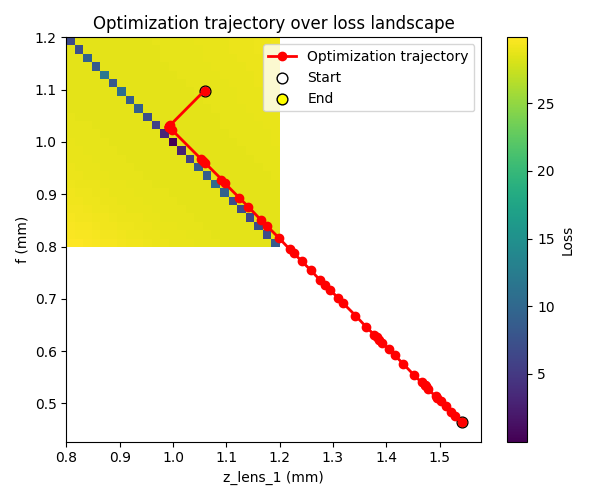

In [12]:
# Plot optimization trajectory on the loss landscape
import numpy as _np
plt.figure(figsize=(6, 5))
plt.imshow(
    _np.asarray(loss_grid),
    origin="lower",
    aspect="auto",
    extent=[z_scan[0] * 1e3, z_scan[-1] * 1e3, f_scan[0] * 1e3, f_scan[-1] * 1e3],
    cmap="viridis",
 )
plt.colorbar(label="Loss")
# convert recorded histories to numpy (ensure they exist)
try:
    z_traj_mm = _np.array(z_history) * 1e3
    f_traj_mm = _np.array(f_history) * 1e3
except NameError:
    z_traj_mm = None
    f_traj_mm = None
if (z_traj_mm is not None) and (f_traj_mm is not None) and len(z_traj_mm) > 0:
    plt.plot(z_traj_mm, f_traj_mm, marker='o', color='red', lw=2, label='Optimization trajectory')
    plt.scatter(z_traj_mm[0], f_traj_mm[0], color='white', edgecolor='black', s=60, label='Start')
    plt.scatter(z_traj_mm[-1], f_traj_mm[-1], color='yellow', edgecolor='black', s=60, label='End')
plt.xlabel("z_lens_1 (mm)")
plt.ylabel("f (mm)")
plt.title("Optimization trajectory over loss landscape")
plt.legend()
plt.tight_layout()

/tmp/ipykernel_132839/532359977.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


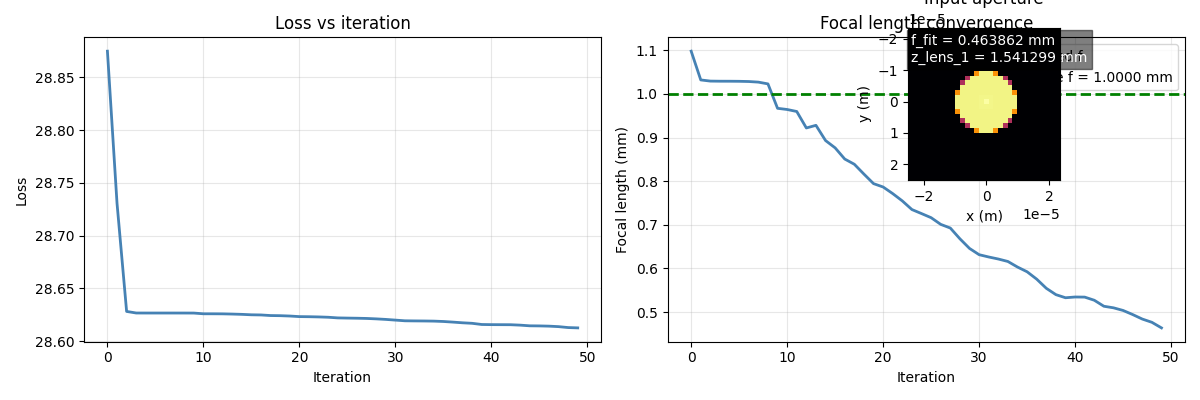

In [13]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))

# Loss during optimization
ax0.plot(loss_history, lw=2, color="steelblue")
ax0.set_xlabel("Iteration")
ax0.set_ylabel("Loss")
ax0.set_title("Loss vs iteration")
ax0.grid(True, alpha=0.3)

# Focal length convergence
iterations = np.arange(len(f_history))
f_history_mm = np.array(f_history) * 1e3
ax1.plot(iterations, f_history_mm, lw=2, color="steelblue", label="Fitted f")
ax1.axhline(f_true * 1e3, color="green", linestyle="--", lw=2, label=f"True f = {f_true*1e3:.4f} mm")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Focal length (mm)")
ax1.set_title("Focal length convergence")
ax1.legend()
ax1.grid(True, alpha=0.3)
# show aperture image in an inset and annotate fitted parameters
f_fit_jax, z_fit_jax = unpack_params(params_init)
f_fit = float(f_fit_jax)
z_fit = float(z_fit_jax)

ax_inset = fig.add_axes([0.68, 0.55, 0.28, 0.38])  # [left, bottom, width, height]
im_ap = ax_inset.imshow(
    np.abs(np.asarray(input_aperture_field)),
    extent=[float(v) for v in input_extent],
    origin="lower",
    cmap="inferno",
)
ax_inset.set_title("Input aperture")
ax_inset.set_xlabel("x (m)")
ax_inset.set_ylabel("y (m)")
ax_inset.text(
    0.02,
    0.96,
    f"f_fit = {f_fit*1e3:.6f} mm\nz_lens_1 = {z_fit*1e3:.6f} mm",
    transform=ax_inset.transAxes,
    va="top",
    color="white",
    bbox=dict(facecolor="black", alpha=0.5, pad=3),
)
fig.tight_layout()


